# Spatio-Temporal AutoEncoder no dataset UCSDPed2
Artigo: https://dl.acm.org/doi/10.1145/3123266.3123451

# Importação das bibliotecas

In [8]:
import os
import glob
import re
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score, roc_auc_score, average_precision_score

# Configuração

In [9]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

kaggle_dataset_folder = '/kaggle/input/datasets/orvile/ucsd-anomaly-dataset/UCSD_Anomaly_Dataset.v1p2/UCSDped2'

base_folder = kaggle_dataset_folder
train_folder = os.path.join(base_folder, 'Train')
test_folder = os.path.join(base_folder, 'Test')
ground_truth_file = os.path.join(test_folder, 'UCSDped2.m')

window_size = 16
prediction_size = 4
img_width = 128
img_height = 128
batch_size = 8
epochs = 30
prediction_loss_weight = 0.3

print('Pasta base:', base_folder)
print('Treino:', train_folder)
print('Teste:', test_folder)
print('Ground truth:', ground_truth_file)

Pasta base: /kaggle/input/datasets/orvile/ucsd-anomaly-dataset/UCSD_Anomaly_Dataset.v1p2/UCSDped2
Treino: /kaggle/input/datasets/orvile/ucsd-anomaly-dataset/UCSD_Anomaly_Dataset.v1p2/UCSDped2/Train
Teste: /kaggle/input/datasets/orvile/ucsd-anomaly-dataset/UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test
Ground truth: /kaggle/input/datasets/orvile/ucsd-anomaly-dataset/UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/UCSDped2.m


# Pré-processamento

In [10]:
# Funções auxiliares
def redimensiona_frame(frame, largura=128, altura=128):
    if len(frame.shape) == 3:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    return cv2.resize(frame, (largura, altura), interpolation=cv2.INTER_AREA)

def normalizar_canal(frame):
    frame = frame.astype(np.float32) / 255.0
    return np.expand_dims(frame, axis=-1)

In [11]:
def get_folders(dataset, prefix):
    folders = []
    for name in sorted(os.listdir(dataset)):
        path = os.path.join(dataset, name)
        if os.path.isdir(path) and name.startswith(prefix):
            folders.append(path)
    return folders

def get_frames(video_folder):
    return sorted(glob.glob(os.path.join(video_folder, '*.tif')))

def preprocess(frame_path):
    frame = cv2.imread(frame_path, cv2.IMREAD_GRAYSCALE)
    frame = redimensiona_frame(frame, largura=img_width, altura=img_height)
    frame = normalizar_canal(frame)
    return frame.astype(np.float32)

def load_video(video_folder):
    frames = []
    for frame_path in get_frames(video_folder):
        frames.append(preprocess(frame_path))
    return np.asarray(frames, dtype=np.float32)

def create_windows(video, window_size=16, prediction_size=4):
    x = []
    y_reconstruction = []
    y_prediction = []
    frame_ids = []

    total_size = window_size + prediction_size
    for start in range(len(video) - total_size + 1):
        input_window = video[start:start + window_size]
        future_window = video[start + window_size:start + total_size]

        x.append(input_window)
        y_reconstruction.append(input_window)
        y_prediction.append(future_window)
        frame_ids.append(start + window_size - 1)

    return (
        np.asarray(x, dtype=np.float32),
        np.asarray(y_reconstruction, dtype=np.float32),
        np.asarray(y_prediction, dtype=np.float32),
        np.asarray(frame_ids, dtype=np.int32)
    )

In [13]:
train_videos = get_folders(train_folder, 'Train')
test_videos = get_folders(test_folder, 'Test')

print('Vídeos de treino:', len(train_videos))
print('Vídeos de teste:', len(test_videos))
print('Frames no primeiro vídeo de treino:', len(get_frames(train_videos[0])))
print('Frames no primeiro vídeo de teste:', len(get_frames(test_videos[0])))

Vídeos de treino: 16
Vídeos de teste: 24
Frames no primeiro vídeo de treino: 120
Frames no primeiro vídeo de teste: 180


In [14]:
data = []
reconstruction_targets = []
prediction_targets = []

for video_folder in train_videos:
    video = load_video(video_folder)
    x, y_rec, y_pred, _ = create_windows(video, window_size, prediction_size)

    data.append(x)
    reconstruction_targets.append(y_rec)
    prediction_targets.append(y_pred)

x_base = np.concatenate(data, axis=0)
y_reconstruction_base = np.concatenate(reconstruction_targets, axis=0)
y_prediction_base = np.concatenate(prediction_targets, axis=0)

print('Entradas:', x_base.shape)
print('Alvo de reconstrução:', y_reconstruction_base.shape)
print('Alvo de predição:', y_prediction_base.shape)

Entradas: (2246, 16, 128, 128, 1)
Alvo de reconstrução: (2246, 16, 128, 128, 1)
Alvo de predição: (2246, 4, 128, 128, 1)


# Visualização dos dados

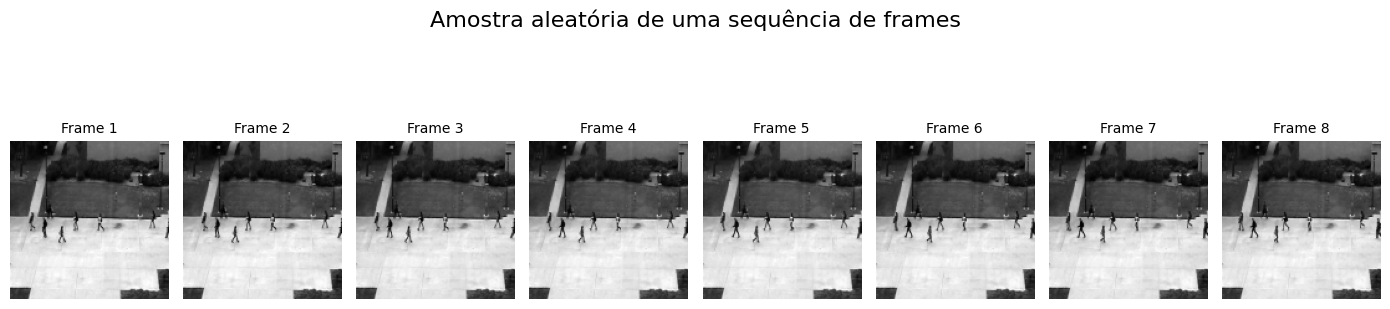

In [28]:
def show_random_sequence(data, n=8):
    index = random.randint(0, len(data) - 1)
    sequence = data[index]

    plt.figure(figsize=(14, 4))
    plt.suptitle('Amostra aleatória de uma sequência de frames', fontsize=16)

    for i in range(min(n, len(sequence))):
        plt.subplot(1, n, i + 1)
        plt.imshow(sequence[i, :, :, 0], cmap='gray')
        plt.title(f'Frame {i + 1}', fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

show_random_sequence(x_base)

# Modelo proposto

In [16]:
def build_model():
    inputs = tf.keras.layers.Input(
        shape=(window_size, img_height, img_width, 1),
        name='input_window'
    )

    # Encoder espaço-temporal com convoluções 3D
    x = tf.keras.layers.Conv3D(32, (3, 3, 3), padding='same', activation='relu')(inputs)
    x = tf.keras.layers.MaxPooling3D((1, 2, 2), padding='same')(x)
    x = tf.keras.layers.Conv3D(64, (3, 3, 3), padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling3D((2, 2, 2), padding='same')(x)
    x = tf.keras.layers.Conv3D(128, (3, 3, 3), padding='same', activation='relu')(x)

    # Decoder de reconstrução
    reconstruction = tf.keras.layers.UpSampling3D((2, 2, 2))(x)
    reconstruction = tf.keras.layers.Conv3D(64, (3, 3, 3), padding='same', activation='relu')(reconstruction)
    reconstruction = tf.keras.layers.UpSampling3D((1, 2, 2))(reconstruction)
    reconstruction = tf.keras.layers.Conv3D(32, (3, 3, 3), padding='same', activation='relu')(reconstruction)
    reconstruction = tf.keras.layers.Conv3D(1, (3, 3, 3), padding='same', activation='sigmoid', name='reconstruction')(reconstruction)

    # Decoder de predição dos próximos frames
    prediction = tf.keras.layers.UpSampling3D((2, 2, 2))(x)
    prediction = tf.keras.layers.Conv3D(64, (3, 3, 3), padding='same', activation='relu')(prediction)
    prediction = tf.keras.layers.UpSampling3D((1, 2, 2))(prediction)
    prediction = tf.keras.layers.Conv3D(32, (3, 3, 3), padding='same', activation='relu')(prediction)
    prediction = tf.keras.layers.Conv3D(1, (3, 3, 3), padding='same', activation='sigmoid')(prediction)
    prediction = tf.keras.layers.Lambda(lambda frames: frames[:, -prediction_size:], name='prediction')(prediction)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=[reconstruction, prediction]
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss=['mse', 'mse'],
        loss_weights=[1.0, prediction_loss_weight]
    )

    return model

model = build_model()
model.summary()

I0000 00:00:1781058333.815038     247 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_window        │ (None, 16, 128,   │          0 │ -                 │
│ (InputLayer)        │ 128, 1)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d (Conv3D)     │ (None, 16, 128,   │        896 │ input_window[0][… │
│                     │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d       │ (None, 16, 64,    │          0 │ conv3d[0][0]      │
│ (MaxPooling3D)      │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_1 (Conv3D)   │ (None, 16, 64,    │     55,360 │ max_pooling3d[0]… │
│                     │ 64, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_1     │ (None, 8, 32, 32, │          0 │ conv3d_1[0][0]    │
│ (MaxPooling3D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_2 (Conv3D)   │ (None, 8, 32, 32, │    221,312 │ max_pooling3d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling3d_2     │ (None, 16, 64,    │          0 │ conv3d_2[0][0]    │
│ (UpSampling3D)      │ 64, 128)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling3d       │ (None, 16, 64,    │          0 │ conv3d_2[0][0]    │
│ (UpSampling3D)      │ 64, 128)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_5 (Conv3D)   │ (None, 16, 64,    │    221,248 │ up_sampling3d_2[… │
│                     │ 64, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_3 (Conv3D)   │ (None, 16, 64,    │    221,248 │ up_sampling3d[0]… │
│                     │ 64, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling3d_3     │ (None, 16, 128,   │          0 │ conv3d_5[0][0]    │
│ (UpSampling3D)      │ 128, 64)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling3d_1     │ (None, 16, 128,   │          0 │ conv3d_3[0][0]    │
│ (UpSampling3D)      │ 128, 64)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_6 (Conv3D)   │ (None, 16, 128,   │     55,328 │ up_sampling3d_3[… │
│                     │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_4 (Conv3D)   │ (None, 16, 128,   │     55,328 │ up_sampling3d_1[… │
│                     │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_7 (Conv3D)   │ (None, 16, 128,   │        865 │ conv3d_6[0][0]    │
│                     │ 128, 1)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reconstruction      │ (None, 16, 128,   │        865 │ conv3d_4[0][0]    │
│ (Conv3D)            │ 128, 1)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prediction (Lambda) │ (None, 4, 128,    │          0 │ conv3d_7[0][0]  

 Total params: 832,450 (3.18 MB)

 Trainable params: 832,450 (3.18 MB)

 Non-trainable params: 0 (0.00 B)

# Divisão em treino e validação e treinamento